# When Cross-Validation Lies: A Controlled Study on Time Series

You fit a model on time-series data, run k-fold cross-validation, and get R² around 0.9.
Is that skill, or an artifact of the split?

On real data you can never be sure, because the true level of predictability is unknown.
So this notebook builds a synthetic dataset where the right answer is known in advance:
the target is constructed so that, in population, **no feature-based predictor can beat R² = 0**.
Then we hand the same data to four different cross-validation schemes and watch what
each one reports.

The short version of what happens, over 30 independent realizations:

| scheme | RandomForest R² (mean ± SD) |
|---|---:|
| KFold, shuffled | **+0.91 ± 0.02** |
| KFold, unshuffled | -1.02 ± 0.85 |
| Walk-forward | -1.26 ± 0.60 |
| Purged k-fold | -1.64 ± 0.93 |

One of these is not like the others. The shuffled split reports strong skill on a target
that contains none, in every single run. The rest correctly report no positive skill.

Everything below is deterministic and self-contained: fixed seeds, no dataset downloads.
The purged and walk-forward splitters come from
[purgedcv](https://github.com/eslazarev/purged-cross-validation)
([PyPI](https://pypi.org/project/purgedcv/)), a small library that plugs into
scikit-learn wherever you currently pass `KFold`.

In [1]:
%pip install -q purgedcv==0.1.1 matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor

from purgedcv import PurgedKFold, WalkForwardSplit
from purgedcv.diagnostics import compute_overlap_fraction

N = 1000        # observations
H = 20          # label horizon: y[t] aggregates noise over the next H steps
N_SPLITS = 5
N_SEEDS = 30    # independent realizations for the Monte Carlo part

pred = pd.Series(pd.date_range("2020-01-01", periods=N, freq="D"))
evalu = pred + pd.Timedelta(days=H)   # when each label is fully known

## How the data is built

Each observation at time `t` is a pair `(x[t], y[t])`:

- **Label**: `y[t] = mean(e[t : t + H])`, where `e` is a separate i.i.d. Gaussian noise
  series that never enters any feature. For a new point independent of the training set,
  `E[y | x] = 0`, so the Bayes predictor based on `x` alone is the constant zero and the
  best achievable population R² is exactly **0**. Any fixed predictor `f(x)`, or one
  trained on independent data, satisfies `R²(f) = -E[f(x)²] / Var(y) ≤ 0`.
- **Feature**: `x` is a monotonically increasing cumulative counter, unrelated to `y`.
  Think account age or running traded volume. Such features are everywhere in real data,
  and because they only grow with time they quietly encode *when* a row is.

The trap is in the label construction. Adjacent labels share `H - 1` of their `H` noise
terms, so `y` is strongly autocorrelated: neighbouring rows have almost the same label.
This mirrors overlapping multi-period returns in finance, rolling aggregates in churn
models, and any target defined over a forward window.

If a split lets the model see a row's temporal neighbours at training time, the model
can read the test label off a neighbour instead of learning anything.

In [3]:
def make_data(seed):
    rng = np.random.default_rng(seed)
    e = rng.standard_normal(N + H - 1)              # N windows of length H
    y = np.array([e[t : t + H].mean() for t in range(N)])
    x = np.cumsum(rng.gamma(shape=2.0, scale=1.0, size=N))
    return x.reshape(-1, 1), y

features, y = make_data(0)
print(f"corr(x, y) = {np.corrcoef(features[:, 0], y)[0, 1]:+.3f} "
      "(spurious finite-sample value; the population relationship is 0 by construction)")

corr(x, y) = -0.217 (spurious finite-sample value; the population relationship is 0 by construction)


## Four ways to split the same data

1. **KFold, shuffled.** A common choice for tabular work (scikit-learn's own default is `shuffle=False`). Test indices are
   scattered across the whole time axis, so every test row sits next to training rows
   with nearly identical labels.
2. **KFold, unshuffled.** Contiguous test blocks, no cleanup. Label overlap survives
   only at the block boundaries.
3. **WalkForwardSplit.** Strictly prospective: each fold trains only on data that
   precedes its test block. This is the closest analogue of deploying a model in real
   time.
4. **PurgedKFold.** Contiguous test blocks, plus a purge: any training row whose label
   window `[prediction_time, evaluation_time)` overlaps the test fold's label windows is
   dropped. The base purge runs off `evaluation_times` alone; the optional
   `purge_horizon` (extra padding) and `embargo` (a gap after the test labels end) are
   left unset here so we see the effect of the base purge in isolation.

Note that 3 and 4 answer slightly different questions. Walk-forward evaluates
prospective forecasting; purged k-fold evaluates generalization to a held-out time
block while using data from both sides of it. Agreement between them is a useful
cross-check.

In [4]:
def make_splitters(seed):
    return {
        "KFold shuffle=True": KFold(N_SPLITS, shuffle=True, random_state=seed),
        "KFold shuffle=False": KFold(N_SPLITS, shuffle=False),
        "WalkForwardSplit": WalkForwardSplit(
            n_splits=N_SPLITS, test_size=N // (N_SPLITS + 1),
            prediction_times=pred, evaluation_times=evalu,
        ),
        "PurgedKFold": PurgedKFold(
            n_splits=N_SPLITS, prediction_times=pred, evaluation_times=evalu,
        ),
    }

def make_models(seed):
    return {
        "predict-the-mean": DummyRegressor(strategy="mean"),
        "k-NN": KNeighborsRegressor(n_neighbors=10),
        "RandomForest": RandomForestRegressor(n_estimators=120, random_state=seed, n_jobs=-1),
    }

## Quick look: one realization

A single run already shows the pattern. Only the shuffled split produces positive
scores, and they are large.

In [5]:
features, y = make_data(0)
splitters = make_splitters(0)

header = f"{'model':<18}" + "".join(f"{s:>22}" for s in splitters)
print(header)
print("-" * len(header))
for m_name, model in make_models(0).items():
    row = f"{m_name:<18}"
    for cv in splitters.values():
        r2 = cross_val_score(model, features, y, cv=cv, scoring="r2").mean()
        row += f"{r2:>+22.3f}"
    print(row)

model                 KFold shuffle=True   KFold shuffle=False      WalkForwardSplit           PurgedKFold
----------------------------------------------------------------------------------------------------------
predict-the-mean                  -0.012                -0.126                -0.309                -0.130
k-NN                              +0.827                -0.327                -0.491                -1.477


RandomForest                      +0.910                -0.524                -0.454                -1.868


## The full experiment: 30 independent realizations

A single seed is an anecdote. To measure the bias systematically we repeat the whole
experiment for 30 seeds. One seed value controls the data generation, the shuffled
split, and the RandomForest internals at once, so the spread below reflects the
combined variability of all three sources.

For each realization we report the arithmetic mean of R² over the five folds; the
table then shows mean ± sample SD (ddof = 1) across the 30 realizations. This takes
a few minutes because of the forests.

In [6]:
agg = {}   # (scheme, model) -> list of per-realization scores
for seed in range(N_SEEDS):
    features, y = make_data(seed)
    for s_name, cv in make_splitters(seed).items():
        for m_name, model in make_models(seed).items():
            r2 = float(cross_val_score(model, features, y, cv=cv, scoring="r2").mean())
            agg.setdefault((s_name, m_name), []).append(r2)

print(f"{'scheme':<22}{'model':<18}{'mean':>9}{'SD':>8}{'positive runs':>15}")
print("-" * 72)
for (s_name, m_name), vals in agg.items():
    a = np.array(vals)
    print(f"{s_name:<22}{m_name:<18}{a.mean():>+9.3f}{a.std(ddof=1):>8.3f}"
          f"{(a > 0).sum():>11}/{N_SEEDS}")

scheme                model                  mean      SD  positive runs
------------------------------------------------------------------------
KFold shuffle=True    predict-the-mean     -0.006   0.004          0/30
KFold shuffle=True    k-NN                 +0.838   0.033         30/30
KFold shuffle=True    RandomForest         +0.912   0.016         30/30
KFold shuffle=False   predict-the-mean     -0.168   0.105          0/30
KFold shuffle=False   k-NN                 -0.948   0.525          0/30
KFold shuffle=False   RandomForest         -1.022   0.849          0/30
WalkForwardSplit      predict-the-mean     -0.246   0.152          0/30
WalkForwardSplit      k-NN                 -1.156   0.741          0/30
WalkForwardSplit      RandomForest         -1.262   0.602          0/30
PurgedKFold           predict-the-mean     -0.176   0.109          0/30
PurgedKFold           k-NN                 -1.301   0.814          0/30
PurgedKFold           RandomForest         -1.636   0.927     

The sign pattern is perfectly consistent. The shuffled KFold is positive for k-NN and
RandomForest in all 30 runs. The other three schemes are negative in all 30 runs, for
both models. Exact values may shift slightly across library versions (the forests
depend on scikit-learn internals); the sign pattern is the reproducible claim.

The exact negative numbers carry no special meaning. They depend on the particular
realization, on training-set sizes, and on how each model extrapolates to a held-out
time block, and the schemes are not directly comparable on that axis: both KFold
variants and PurgedKFold test all 1000 observations in folds of 200, while
WalkForwardSplit tests only the last 830 in folds of 166, with training sets ranging
from 151 to 815 rows. What matters is the qualitative agreement: no scheme without
test points scattered among their neighbours ever reports positive skill, which is the
correct answer here.

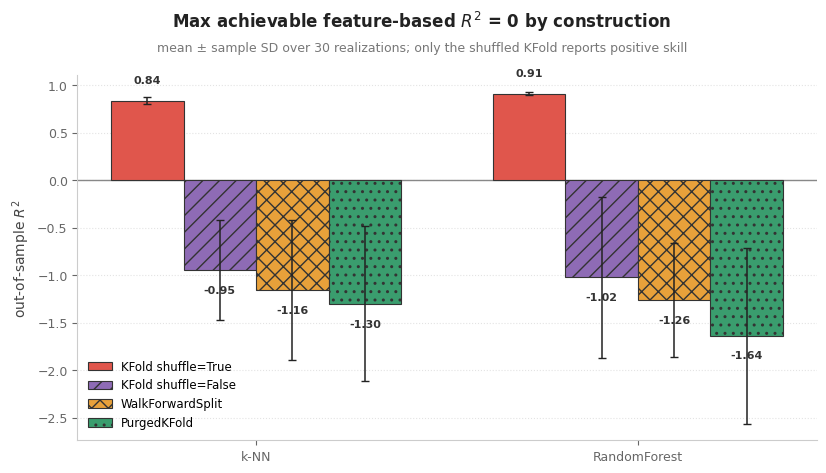

In [7]:
PLOT_MODELS = ["k-NN", "RandomForest"]
SCHEMES = ["KFold shuffle=True", "KFold shuffle=False", "WalkForwardSplit", "PurgedKFold"]
colors = dict(zip(SCHEMES, ["#e0564c", "#8e6bb5", "#e8a13a", "#3a9d6e"], strict=True))
hatches = dict(zip(SCHEMES, ["", "//", "xx", ".."], strict=True))

width = 0.19
xpos = np.arange(len(PLOT_MODELS))

fig, ax = plt.subplots(figsize=(8.4, 4.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, s_name in enumerate(SCHEMES):
    means = [np.mean(agg[(s_name, m)]) for m in PLOT_MODELS]
    sds = [np.std(agg[(s_name, m)], ddof=1) for m in PLOT_MODELS]
    bars = ax.bar(xpos + (i - 1.5) * width, means, width, yerr=sds, capsize=3,
                  label=s_name, color=colors[s_name], hatch=hatches[s_name],
                  edgecolor="#333333", linewidth=0.8, zorder=3,
                  error_kw={"ecolor": "#222222", "elinewidth": 1.1})
    for rect, mval in zip(bars, means, strict=True):
        offset = 0.16 if mval >= 0 else -0.16
        ax.text(rect.get_x() + rect.get_width() / 2, mval + offset, f"{mval:.2f}",
                ha="center", va="bottom" if mval >= 0 else "top",
                fontsize=8, fontweight="bold", color="#333333")

ax.axhline(0.0, color="#888888", lw=1, zorder=2)
ax.set_xticks(xpos, PLOT_MODELS)
ax.set_ylabel("out-of-sample $R^2$", fontsize=10, color="#444444")
ax.tick_params(colors="#666666", labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#cccccc")
ax.grid(axis="y", ls=":", color="#dddddd", alpha=0.8, zorder=0)

fig.text(0.5, 0.96, "Max achievable feature-based $R^2$ = 0 by construction",
         ha="center", fontsize=12, fontweight="bold", color="#222222")
fig.text(0.5, 0.91, "mean ± sample SD over 30 realizations; only the shuffled KFold reports positive skill",
         ha="center", fontsize=9, color="#777777")
ax.legend(frameon=False, fontsize=8.5, loc="lower left")
fig.subplots_adjust(top=0.86, bottom=0.10, left=0.09, right=0.97)
plt.show()

## Why it happens: label-window overlap

`compute_overlap_fraction` measures, for each fold, the share of training rows whose
label window intersects the test fold's label windows.

In [8]:
features, y = make_data(0)
for name, cv in make_splitters(0).items():
    fr = [compute_overlap_fraction(tr, te, pred, evalu)
          for tr, te in cv.split(features, y)]
    print(f"{name:<22}: {np.mean(fr):6.1%} of training rows overlap the test labels")

KFold shuffle=True    : 100.0% of training rows overlap the test labels


KFold shuffle=False   :   3.8% of training rows overlap the test labels
WalkForwardSplit      :   0.0% of training rows overlap the test labels
PurgedKFold           :   0.0% of training rows overlap the test labels


Under the shuffled split, 100% of training rows have a label window that intersects the
test labels: for every test point the training set contains rows with almost the same
label, and a flexible model can read them back out. That picture is consistent with
leakage through overlap, although the overlap share alone does not prove that the whole
observed R² flows through this one channel.

The unshuffled KFold is a telling contrast. It keeps a small 3.8% boundary overlap, yet
already reports negative scores. So a small residual overlap was not enough to produce
positive mean R² here; the positive result appears when test points are densely
interleaved with training neighbours and 100% of training rows overlap. The two
conditions differ in several factors at once (test-point placement, overlap share,
nearest-neighbour availability), so this experiment does not isolate the contribution
of each factor separately.

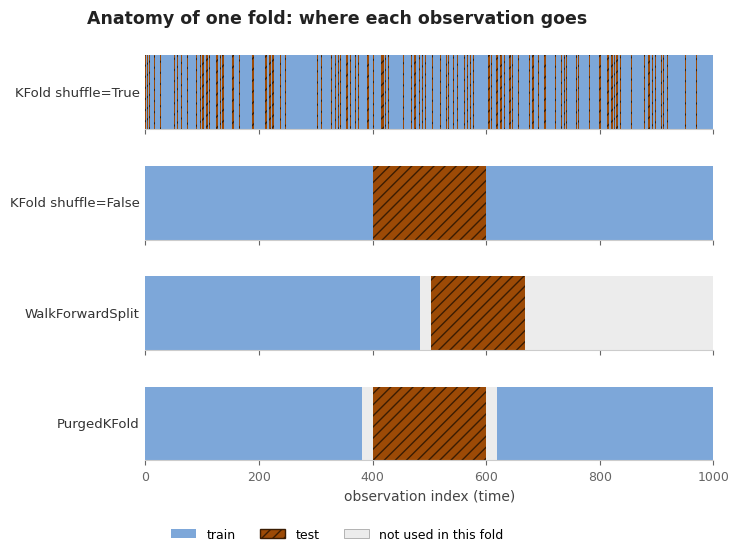

In [9]:
TRAIN_C, TEST_C, DROP_C = "#7da7d9", "#9c4a06", "#ececec"

def fold_status(splitter, fold_idx):
    for i, (tr, te) in enumerate(splitter.split(features, y)):
        if i == fold_idx:
            status = np.full(N, 2)   # 2 = not used in this fold
            status[tr] = 0           # 0 = train
            status[te] = 1           # 1 = test
            return status
    raise IndexError(fold_idx)

def status_runs(status):
    edges = np.flatnonzero(np.diff(status)) + 1
    starts = np.concatenate(([0], edges))
    ends = np.concatenate((edges, [len(status)]))
    return [(int(s), int(e - s), int(status[s])) for s, e in zip(starts, ends, strict=True)]

STYLE = {
    0: {"facecolor": TRAIN_C, "hatch": None, "edgecolor": "none"},
    1: {"facecolor": TEST_C, "hatch": "///", "edgecolor": "#3a1c02"},
    2: {"facecolor": DROP_C, "hatch": None, "edgecolor": "none"},
}

rows = [(name, fold_status(cv, 2)) for name, cv in make_splitters(0).items()]

fig, axes = plt.subplots(4, 1, figsize=(8, 5.4), sharex=True)
fig.patch.set_facecolor("white")
for ax, (title, status) in zip(axes, rows, strict=True):
    ax.set_facecolor("white")
    for start, length, value in status_runs(status):
        st = STYLE[value]
        ax.add_patch(plt.Rectangle((start, 0), length, 1,
                                   facecolor=st["facecolor"], hatch=st["hatch"],
                                   edgecolor=st["edgecolor"], linewidth=0.0, zorder=2))
    ax.set_xlim(0, N)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel(title, rotation=0, ha="right", va="center", fontsize=9.5, color="#333333")
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="#666666", labelsize=9)
axes[-1].set_xlabel("observation index (time)", fontsize=10, color="#444444")

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=TRAIN_C, edgecolor="none"),
    plt.Rectangle((0, 0), 1, 1, facecolor=TEST_C, hatch="///", edgecolor="#3a1c02"),
    plt.Rectangle((0, 0), 1, 1, facecolor=DROP_C, edgecolor="#999999", linewidth=0.5),
]
fig.legend(handles, ["train", "test", "not used in this fold"],
           ncol=3, frameon=False, fontsize=9, loc="lower center",
           bbox_to_anchor=(0.5, -0.02))
fig.text(0.5, 0.96, "Anatomy of one fold: where each observation goes",
         ha="center", fontsize=12.5, fontweight="bold", color="#222222")
fig.subplots_adjust(top=0.90, bottom=0.15, left=0.26, right=0.97, hspace=0.5)
plt.show()

The top strip is the mechanism in one picture: hundreds of thin test stripes, each
surrounded by training neighbours. The other three schemes test one contiguous block.
PurgedKFold additionally removes the narrow strips next to the block where label
windows cross the boundary.

## What if you get the label horizon wrong?

The purge relies on `evaluation_times`, that is, on knowing when each label's window
actually ends. Here we hand `PurgedKFold` a range of assumed label horizons and measure
how much true overlap still leaks into training, scored against the real horizon
`H = 20`.

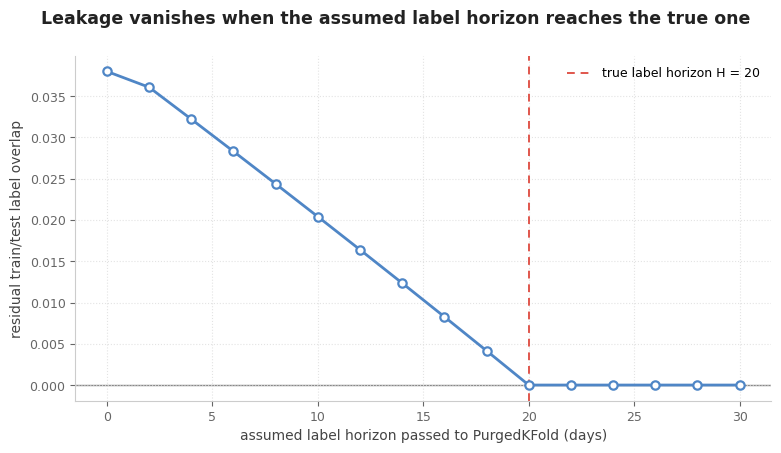

residual overlap at assumed = 0 : 0.0380
residual overlap at assumed = H : 0.0000


In [10]:
horizons = list(range(0, int(1.5 * H) + 1, 2))
residual = []
for assumed in horizons:
    cv_p = PurgedKFold(
        n_splits=N_SPLITS,
        prediction_times=pred,
        evaluation_times=pred + pd.Timedelta(days=assumed),
    )
    fr = [compute_overlap_fraction(tr, te, pred, evalu)   # evalu = the TRUE horizon
          for tr, te in cv_p.split(features, y)]
    residual.append(float(np.mean(fr)))

fig, ax = plt.subplots(figsize=(8, 4.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.plot(horizons, residual, marker="o", color="#4f86c6", lw=2,
        markerfacecolor="white", markeredgecolor="#4f86c6",
        markeredgewidth=1.6, zorder=3)
ax.axvline(H, color="#e0564c", ls=(0, (4, 3)), lw=1.4,
           label=f"true label horizon H = {H}", zorder=2)
ax.axhline(0.0, color="#888888", lw=1, zorder=1)
ax.set_xlabel("assumed label horizon passed to PurgedKFold (days)", fontsize=10, color="#444444")
ax.set_ylabel("residual train/test label overlap", fontsize=10, color="#444444")
ax.tick_params(colors="#666666", labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#cccccc")
ax.grid(ls=":", color="#dddddd", alpha=0.8, zorder=0)
fig.text(0.5, 0.95, "Leakage vanishes when the assumed label horizon reaches the true one",
         ha="center", fontsize=12.5, fontweight="bold", color="#222222")
ax.legend(frameon=False, fontsize=9)
fig.subplots_adjust(top=0.88, bottom=0.13, left=0.10, right=0.97)
plt.show()

print(f"residual overlap at assumed = 0 : {residual[0]:.4f}")
print(f"residual overlap at assumed = H : {residual[horizons.index(H)]:.4f}")

The residual overlap falls roughly linearly and reaches zero exactly when the assumed
horizon matches the true one. Understate the horizon by even a little and some leakage
remains. Overstating it adds no leakage; it just shrinks the training set.

So `evaluation_times` must reflect the actual end of each label's window. The optional
`purge_horizon` parameter adds a safety margin on top of that; it is not a substitute
for getting `evaluation_times` right.

## Takeaways

- A shuffled k-fold reported R² of about 0.9 on a target that no feature-based
  predictor can beat zero on, in 30 out of 30 runs. The estimate exceeds the
  theoretical upper bound of the population R² by roughly 0.9.
- Three schemes that do not scatter test points among their training neighbours
  (unshuffled KFold, walk-forward, purged k-fold) gave the same qualitative answer:
  no positive skill, in 30 out of 30 runs each.
- The synthetic setup doubles as a cheap placebo test for your own pipeline: run your
  CV scheme on data where the right answer is a known zero. If it systematically
  reports positive skill across repeated realizations, the scheme does not match a
  forecasting task, whatever the score on real data says.

The splitters used here are from [purgedcv](https://github.com/eslazarev/purged-cross-validation)
([PyPI](https://pypi.org/project/purgedcv/), `pip install purgedcv`). They follow the
scikit-learn splitter interface, so `cross_val_score`, `GridSearchCV`, and `Pipeline`
work unchanged. The library also implements Combinatorial Purged Cross-Validation,
which builds several backtest paths from one sample.

Further reading: Bergmeir & Benítez (2012), *On the use of cross-validation for time
series predictor evaluation*; López de Prado (2018), *Advances in Financial Machine
Learning*, ch. 7; Bailey, Borwein, López de Prado & Zhu (2017), *The probability of
backtest overfitting*.